# Task 1 — Movie Genre Classification

**CodSoft ML Internship**

Predict a film's genre from its plot summary.

- **Dataset:** [IMDb Genre Classification](https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb) — 54,214 training films and 54,200 test films across **27 genres**, derived from the IMDb plot database.
- **Approach:** TF-IDF over the plot text → linear classifier, in a scikit-learn `Pipeline`.
- **Headline metric:** **macro-F1**, not accuracy. Two genres (drama and documentary) are half the
  dataset, so accuracy is decided almost entirely by how well the model does on those two. Macro-F1
  averages the per-class F1 scores with equal weight, so the 132 war films count as much as the
  13,612 dramas.

This dataset has a genuinely low ceiling — expect accuracy around 60%. A large part of this notebook
is about **why**, because that explanation is worth more than another point of accuracy.

In [1]:
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)
DATA = "data/"

---
## 1. Parsing the data

These are **not** CSVs. Each line is `:::`-delimited:

```
ID ::: TITLE ::: GENRE ::: DESCRIPTION          <- train_data.txt, test_data_solution.txt
ID ::: TITLE ::: DESCRIPTION                    <- test_data.txt (no label)
```

`pd.read_csv` handles it with `sep=" ::: "` and `engine="python"` — the C parser only accepts
single-character separators, so the Python engine is required. Note the spaces around the colons are
part of the separator.

The dataset ships a **real held-out test set with its own solution file**, so we evaluate on that
rather than carving a validation split out of the training data. That is a stronger test: 54,200
films the model has never seen, labelled independently.

In [2]:
def read_delimited(filename, columns):
    df = pd.read_csv(DATA + filename, sep=" ::: ", engine="python",
                     names=columns, encoding="utf-8")
    for col in df.columns[1:]:
        df[col] = df[col].str.strip()
    return df

train = read_delimited("train_data.txt", ["id", "title", "genre", "description"])
test = read_delimited("test_data.txt", ["id", "title", "description"])
solution = read_delimited("test_data_solution.txt", ["id", "title", "genre", "description"])

print(f"train    : {train.shape}")
print(f"test     : {test.shape}")
print(f"solution : {solution.shape}")
train.head(3)

train    : (54214, 4)
test     : (54200, 3)
solution : (54200, 4)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,"Listening in to a conversation between his doctor and parents, 10-year-old O..."
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous relationship have a current murd...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their field trip to the Museum of Natura...


### 1.1 Sanity checks before trusting any of it

In [3]:
print("missing values:")
print(f"  train    {train.isna().sum().sum()}")
print(f"  solution {solution.isna().sum().sum()}")

print(f"\ntest and solution rows line up by id : {(test['id'].values == solution['id'].values).all()}")
print(f"test and solution descriptions match : "
      f"{(test['description'].values == solution['description'].values).all()}")

overlap = len(set(train["description"]) & set(solution["description"]))
print(f"\ndescriptions appearing in both train and test : {overlap} "
      f"({overlap / len(solution):.3%} of the test set)")
print(f"duplicate descriptions within train           : {train['description'].duplicated().sum()}")

missing values:
  train    0
  solution 0

test and solution rows line up by id : True
test and solution descriptions match : True

descriptions appearing in both train and test : 91 (0.168% of the test set)
duplicate descriptions within train           : 128


The two test files line up exactly, so `test_data_solution.txt` is a trustworthy label source.

There is a small leak: **91 plot summaries appear in both train and test** (0.17% of the test set).
That is too small to move the headline number meaningfully, but it should be stated rather than
discovered later — at this size it inflates accuracy by at most ~0.17 percentage points.

---
## 2. The genre distribution — the central fact of this dataset

27 genres
largest : drama         13613 (25.1%)
smallest: war             132 (0.2%)
ratio largest:smallest = 103 : 1

drama + documentary = 49.3% of all films
accuracy of an 'always predict drama' baseline: 25.11%


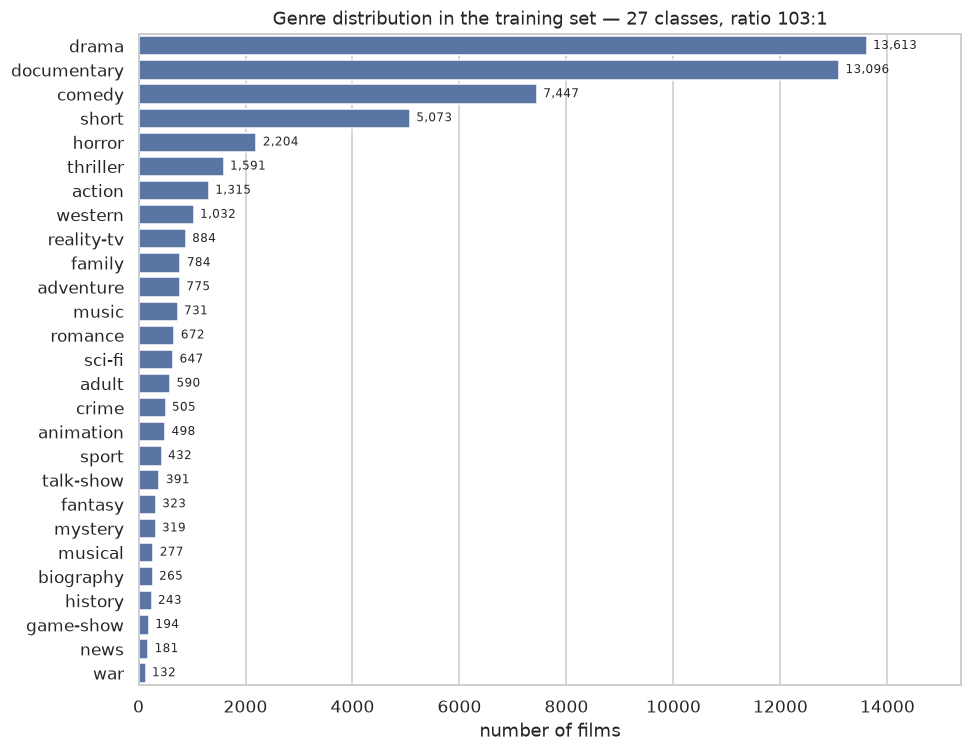

In [4]:
counts = train["genre"].value_counts()
print(f"{len(counts)} genres")
print(f"largest : {counts.index[0]:12s} {counts.iloc[0]:6d} ({counts.iloc[0] / len(train):.1%})")
print(f"smallest: {counts.index[-1]:12s} {counts.iloc[-1]:6d} ({counts.iloc[-1] / len(train):.1%})")
print(f"ratio largest:smallest = {counts.iloc[0] / counts.iloc[-1]:.0f} : 1")
print(f"\ndrama + documentary = {(counts.iloc[0] + counts.iloc[1]) / len(train):.1%} of all films")
print(f"accuracy of an 'always predict drama' baseline: {counts.iloc[0] / len(train):.2%}")

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#4c72b0")
for i, v in enumerate(counts.values):
    ax.text(v + 120, i, f"{v:,}", va="center", fontsize=8)
ax.set(title="Genre distribution in the training set — 27 classes, ratio 103:1",
       xlabel="number of films", ylabel="")
ax.set_xlim(0, counts.max() * 1.13)
fig.tight_layout()
fig.savefig("results/genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### What this distribution means for the metrics

The imbalance is **extreme and long-tailed**: drama has 13,612 films, war has 132 — a ratio of about
103 to 1. Drama and documentary together are **49.3%** of the dataset.

Three consequences:

1. **Accuracy is nearly meaningless.** Predicting "drama" for every single film scores 25.1%. A model
   that learns only drama and documentary well, and nothing else, can reach the high 40s while being
   useless for 25 of the 27 genres.
2. **Macro-F1 is the honest metric.** It computes F1 per genre and averages them with equal weight,
   so failure on war or biography costs exactly as much as failure on drama. That is what we report.
3. **`class_weight="balanced"` matters here.** Without it, the loss is dominated by the two big
   genres and the rare ones are simply never predicted. We use it wherever the classifier supports it.

### 2.1 Plot length

       n_chars  n_words
count  54214.0  54214.0
mean     599.5    101.9
std      446.0     76.6
min       41.0      6.0
25%      324.0     55.0
50%      463.0     79.0
75%      712.0    121.0
max    10503.0   1829.0


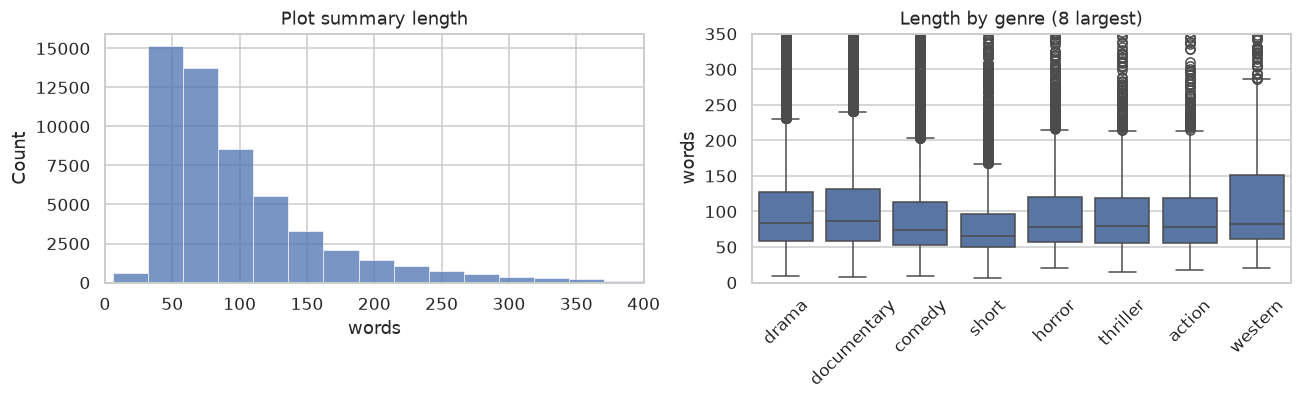

In [5]:
train["n_chars"] = train["description"].str.len()
train["n_words"] = train["description"].str.split().str.len()
print(train[["n_chars", "n_words"]].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(train["n_words"], bins=70, ax=axes[0], color="#4c72b0")
axes[0].set(title="Plot summary length", xlabel="words", xlim=(0, 400))

top8 = counts.head(8).index
sns.boxplot(data=train[train["genre"].isin(top8)], x="genre", y="n_words",
            order=top8, ax=axes[1], color="#4c72b0")
axes[1].set(title="Length by genre (8 largest)", xlabel="", ylabel="words", ylim=(0, 350))
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig("results/plot_length.png", dpi=150, bbox_inches="tight")
plt.show()

Summaries are short — a median of about 80 words — and the length distributions overlap almost
completely across genres. **Length carries no genre signal**, so everything has to come from
vocabulary. That is also why TF-IDF's row normalisation is the right default here: we want the model
comparing word *proportions*, not raw counts that vary with how verbose a summary happens to be.

---
## 3. Features

TF-IDF over the plot text, with:

- **`ngram_range=(1,2)`** — unigrams plus bigrams. Bigrams catch phrases like "world war",
  "high school", "serial killer" that single words miss.
- **`sublinear_tf=True`** — replaces raw count with $1 + \log(\mathrm{tf})$. The fifth mention of
  "love" is not five times more informative than the first.
- **`min_df=2`** — drop terms appearing in only one film. On 54k documents these are almost all
  proper nouns and typos, and they cannot generalise by definition.
- **`stop_words="english"`** — "the", "of", "and" appear in every plot regardless of genre.

We also test whether **concatenating the title** helps. Titles are short but often carry genre
signal directly (*Blood Feast*, *The Cowboy and the Lady*). The year in brackets is stripped first —
it is metadata, not a word.

In [6]:
def strip_year(titles):
    return titles.str.replace(r"\s*\(.*\)\s*$", "", regex=True)

feature_sets = {
    "description only": (
        train["description"],
        solution["description"],
    ),
    "title + description": (
        strip_year(train["title"]) + " . " + train["description"],
        strip_year(solution["title"]) + " . " + solution["description"],
    ),
}

def make_vectorizer():
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2,
                           stop_words="english", strip_accents="unicode")

y_train, y_test = train["genre"], solution["genre"]
print(f"training labels: {y_train.nunique()} genres over {len(y_train):,} films")
print(f"test labels    : {y_test.nunique()} genres over {len(y_test):,} films")

training labels: 27 genres over 54,214 films
test labels    : 27 genres over 54,200 films


---
## 4. Model comparison

Two feature sets, three classifiers, evaluated on the **real held-out test set**.

`class_weight="balanced"` is used for `LogisticRegression` and `LinearSVC`. `MultinomialNB` has no
such parameter — it learns class priors directly from the data, which turns out to matter a lot.

*(This cell fits six models over ~300,000 features and takes a few minutes.)*

In [7]:
classifiers = {
    "MultinomialNB": lambda: MultinomialNB(),
    "LogisticRegression": lambda: LogisticRegression(class_weight="balanced", max_iter=100,
                                                     random_state=RANDOM_STATE),
    "LinearSVC": lambda: LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

rows, predictions = [], {}
for fs_name, (X_tr, X_te) in feature_sets.items():
    for clf_name, make_clf in classifiers.items():
        pipe = Pipeline([("tfidf", make_vectorizer()), ("clf", make_clf())]).fit(X_tr, y_train)
        pred = pipe.predict(X_te)
        key = f"{clf_name} / {fs_name}"
        predictions[key] = pred
        rows.append({
            "features": fs_name,
            "model": clf_name,
            "accuracy": accuracy_score(y_test, pred),
            "macro F1": f1_score(y_test, pred, average="macro"),
            "weighted F1": f1_score(y_test, pred, average="weighted"),
            "genres ever predicted": len(np.unique(pred)),
        })
        print(f"  fitted {key}")

results = pd.DataFrame(rows).sort_values("macro F1", ascending=False).reset_index(drop=True)
results.style.format({"accuracy": "{:.4f}", "macro F1": "{:.4f}", "weighted F1": "{:.4f}"}) \
       .background_gradient(subset=["macro F1"], cmap="Greens")

  fitted MultinomialNB / description only


  fitted LogisticRegression / description only


  fitted LinearSVC / description only


  fitted MultinomialNB / title + description


  fitted LogisticRegression / title + description


  fitted LinearSVC / title + description


,features,model,accuracy,macro F1,weighted F1,genres ever predicted
0,title + description,LinearSVC,0.6025,0.4114,0.5940,27
1,description only,LinearSVC,0.5952,0.3971,0.5871,27
2,title + description,LogisticRegression,0.5294,0.3939,0.5451,27
3,description only,LogisticRegression,0.5228,0.3852,0.5391,27
4,description only,MultinomialNB,0.4468,0.0486,0.3068,6
5,title + description,MultinomialNB,0.4462,0.0482,0.3054,6


### Reading the table

**LinearSVC wins on both feature sets**, and adding the title helps a little — worth keeping, but the
plot text is doing nearly all the work.

**Look at the last column: how many of the 27 genres each model ever predicts.** This is where naive
Bayes falls apart. Its accuracy looks like a respectable mid-40s, but its macro-F1 is near **0.05**,
because it predicts only **6 of the 27 genres** and never emits the other 21 at all. Every one of
those gets an F1 of exactly zero.

That is the single clearest demonstration in this project of why accuracy is the wrong metric: NB's
accuracy is roughly three-quarters of LinearSVC's, while its macro-F1 is about one-eighth of it.

The reason is the class priors. NB multiplies its likelihood by $P(\text{genre})$, and with drama at
25% and war at 0.24%, the prior swamps the evidence for every small class. `class_weight="balanced"`
is exactly the correction the linear models get and NB does not.

In [8]:
best_key = f"{results.iloc[0]['model']} / {results.iloc[0]['features']}"
best_pred = predictions[best_key]
print(f"winner: {best_key}\n")
print(f"accuracy : {accuracy_score(y_test, best_pred):.4f}")
print(f"macro F1 : {f1_score(y_test, best_pred, average='macro'):.4f}")
print(f"vs 'always drama' baseline accuracy: {(y_test == 'drama').mean():.4f}")

winner: LinearSVC / title + description

accuracy : 0.6025


macro F1 : 0.4114
vs 'always drama' baseline accuracy: 0.2511


---
## 5. Per-genre results — which genres does it fail on?

The headline macro-F1 hides enormous variation between genres. This is the most informative table in
the notebook.

In [9]:
report = pd.DataFrame(classification_report(
    y_test, best_pred, output_dict=True, zero_division=0)).T
per_genre = report.drop(["accuracy", "macro avg", "weighted avg"]).sort_values("f1-score",
                                                                               ascending=False)
per_genre["support"] = per_genre["support"].astype(int)
print(per_genre.round(3).to_string())

             precision  recall  f1-score  support
western          0.753   0.925     0.830     1032
documentary      0.745   0.813     0.778    13096
game-show        0.716   0.720     0.718      193
drama            0.660   0.631     0.645    13612
horror           0.555   0.755     0.640     2204
comedy           0.609   0.599     0.604     7446
music            0.517   0.709     0.598      731
adult            0.520   0.637     0.573      590
sport            0.500   0.596     0.544      431
sci-fi           0.439   0.520     0.476      646
short            0.509   0.394     0.444     5072
talk-show        0.450   0.437     0.444      391
action           0.386   0.502     0.436     1314
reality-tv       0.413   0.442     0.427      883
war              0.385   0.379     0.382      132
adventure        0.392   0.321     0.353      775
animation        0.342   0.251     0.290      498
family           0.304   0.268     0.285      783
news             0.380   0.227     0.284      181


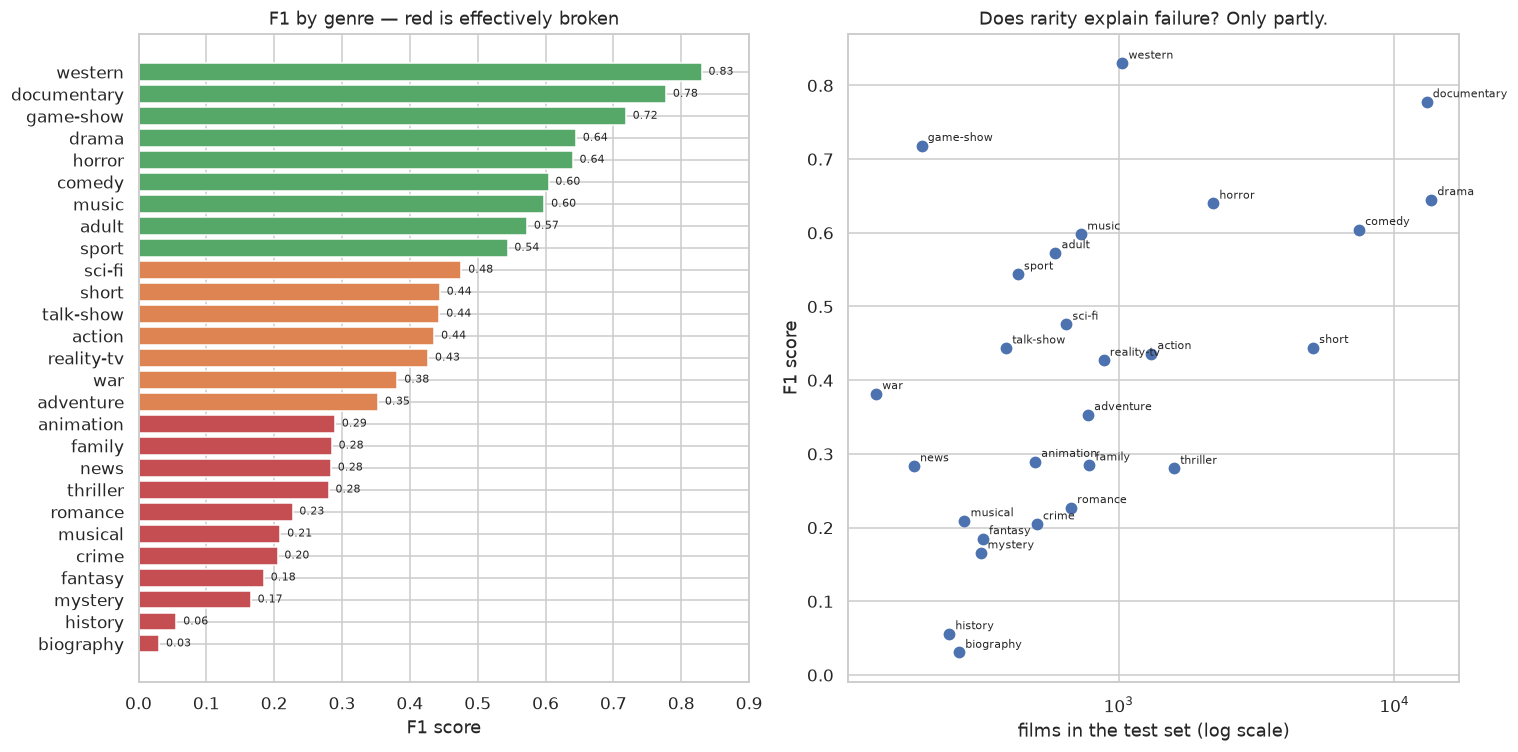

Spearman correlation between genre size and F1: 0.535


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

order = per_genre.sort_values("f1-score")
colors = ["#c44e52" if v < 0.30 else "#dd8452" if v < 0.50 else "#55a868"
          for v in order["f1-score"]]
axes[0].barh(order.index, order["f1-score"], color=colors)
axes[0].set(title="F1 by genre — red is effectively broken", xlabel="F1 score", xlim=(0, 0.9))
for i, v in enumerate(order["f1-score"]):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)

axes[1].scatter(per_genre["support"], per_genre["f1-score"], s=45, color="#4c72b0")
for genre, row in per_genre.iterrows():
    axes[1].annotate(genre, (row["support"], row["f1-score"]), fontsize=7,
                     xytext=(4, 3), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set(title="Does rarity explain failure? Only partly.",
            xlabel="films in the test set (log scale)", ylabel="F1 score")

fig.tight_layout()
fig.savefig("results/per_genre_f1.png", dpi=150, bbox_inches="tight")
plt.show()

rho = per_genre["support"].corr(per_genre["f1-score"], method="spearman")
print(f"Spearman correlation between genre size and F1: {rho:.3f}")

### The genres it fails on

**Broken (F1 below 0.20):** biography (0.03), history (0.06), mystery (0.17), fantasy (0.19) —
with crime, musical and romance barely clear of it at 0.21–0.23.

**biography and history are near-total failures.** Biography recall is 0.019: of 264 biographies in
the test set the model finds five. Both have a blank diagonal in the confusion matrix below — it
almost never predicts either label at all.

**Best (F1 above 0.60):** western (0.83), documentary (0.78), game-show (0.72), drama (0.65),
horror (0.64), comedy (0.60).

### Why? It is not simply that rare genres fail

Genre size and F1 correlate at only **ρ = 0.535** — a moderate relationship that leaves most of
the variation unexplained. The counterexamples are the interesting part:

| Small but classified well | Large but classified badly |
|---|---|
| western (1,032 films, F1 **0.83** — the best of all 27) | short (5,072 films, F1 0.44) |
| game-show (193 films, F1 **0.72**) | thriller (1,590 films, F1 0.28) |
| sport, music, adult (all under 1,100, all above F1 0.54) | action (1,314 films, F1 0.44) |

The pattern is not size, it is **vocabulary distinctiveness**. Westerns talk about sheriffs,
outlaws, saloons and the frontier — a vocabulary that appears nowhere else, so 1,032 examples are
plenty. Thrillers are described with the same words as dramas and crime films, so 1,590 examples
do not help.

**Genres defined by their setting or subject are learnable from text. Genres defined by narrative
structure or emotional tone are not.**

---
## 6. The confusion matrix

Row-normalised, so each row shows where films of that true genre actually went.

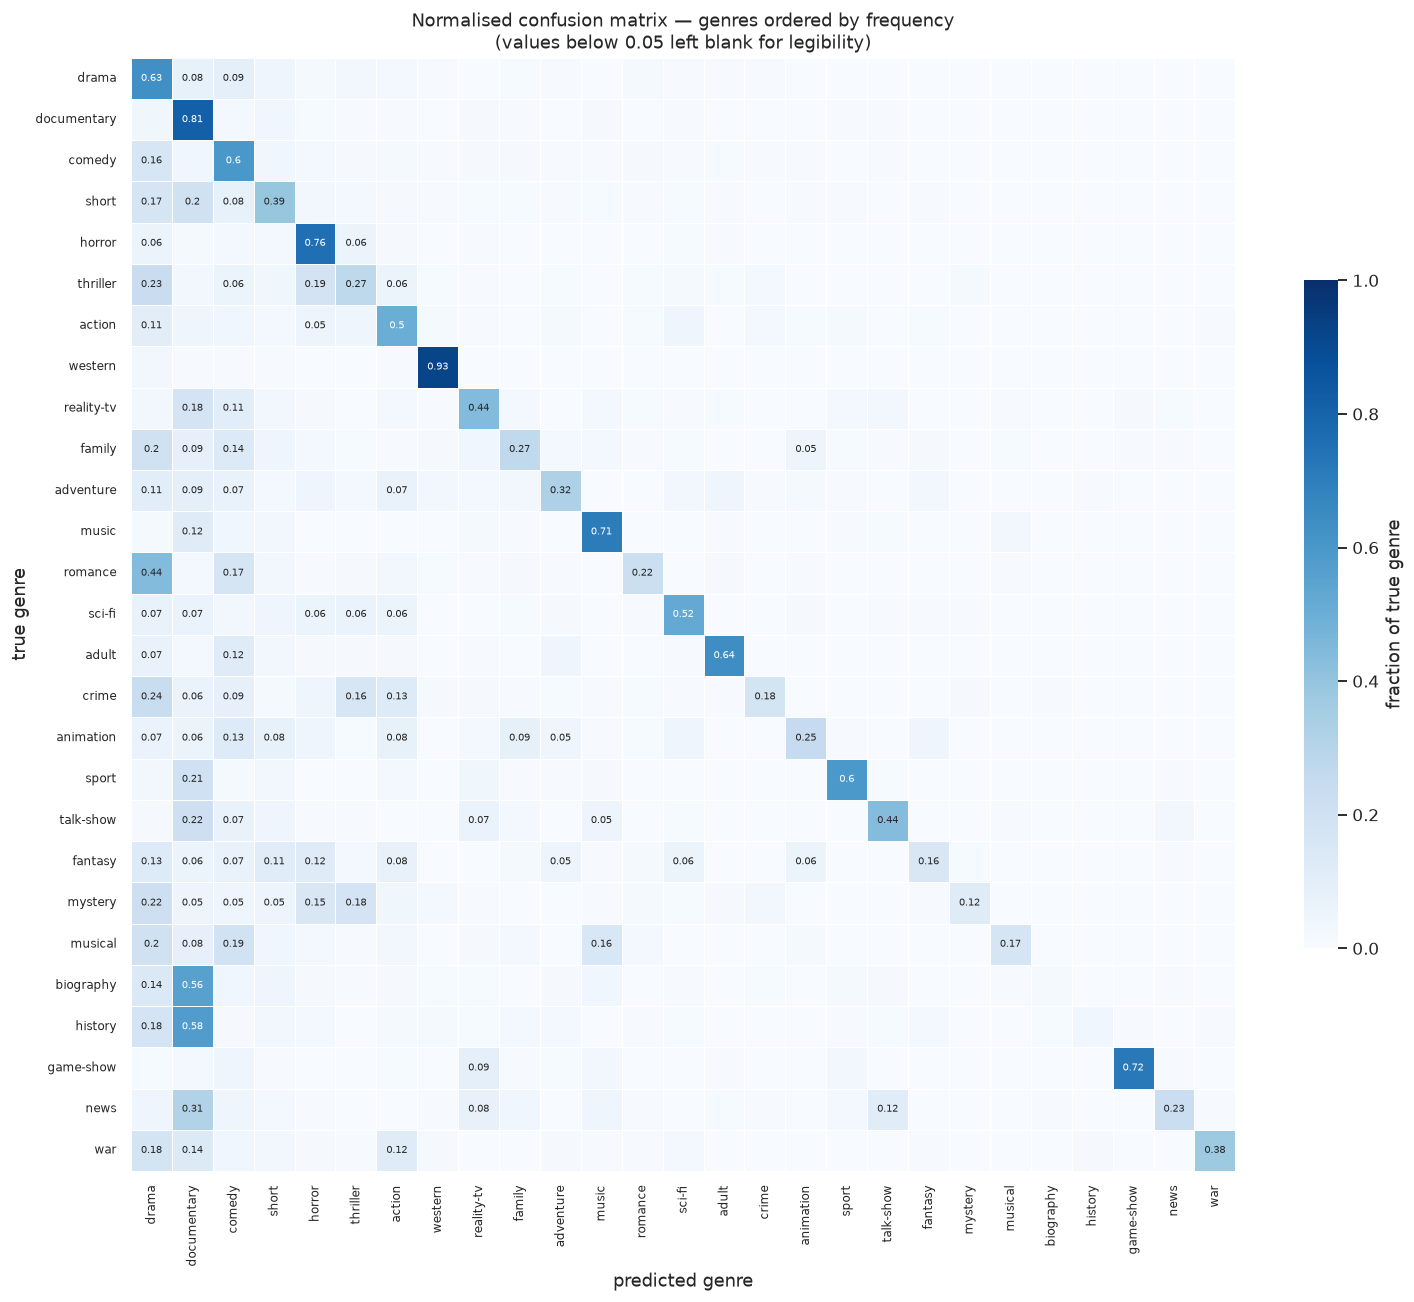

In [11]:
genre_order = list(counts.index)          # most common first
cm = confusion_matrix(y_test, best_pred, labels=genre_order, normalize="true")

annot = np.where(cm >= 0.05, np.round(cm, 2).astype(str), "")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1,
            xticklabels=genre_order, yticklabels=genre_order,
            linewidths=0.4, linecolor="white", ax=ax,
            annot_kws={"size": 6.5}, cbar_kws={"shrink": 0.6, "label": "fraction of true genre"})
ax.set(title="Normalised confusion matrix — genres ordered by frequency\n"
             "(values below 0.05 left blank for legibility)",
       xlabel="predicted genre", ylabel="true genre")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
fig.tight_layout()
fig.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
off_diagonal = [
    {"true genre": genre_order[i], "predicted as": genre_order[j], "fraction": cm[i, j]}
    for i in range(len(genre_order)) for j in range(len(genre_order)) if i != j
]
top_confusions = (pd.DataFrame(off_diagonal)
                  .sort_values("fraction", ascending=False)
                  .head(15).reset_index(drop=True))
print("The 15 mistakes the model makes most often:\n")
print(top_confusions.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

The 15 mistakes the model makes most often:

true genre predicted as  fraction
   history  documentary     0.580
 biography  documentary     0.557
   romance        drama     0.442
      news  documentary     0.315
     crime        drama     0.236
  thriller        drama     0.231
 talk-show  documentary     0.217
   mystery        drama     0.217
     sport  documentary     0.206
    family        drama     0.202
     short  documentary     0.201
   musical        drama     0.196
   musical       comedy     0.192
  thriller       horror     0.186
       war        drama     0.182


---
## 7. Why the ceiling is low — and why chasing it is the wrong move

Read that list of confusions again. **The model is not making random errors.**

| True genre | Sent to | How often |
|---|---|---|
| history | documentary | 58% |
| biography | documentary | 56% |
| romance | drama | 44% |
| news | documentary | 32% |
| crime, thriller, mystery, family | drama | 20–24% each |
| thriller | horror | 19% |
| musical | comedy | 19% |

Every one of these is **semantically defensible**. A biography *is* a documentary about a person's
life. A history film *is* a documentary about the past. A romance *is* a drama in which people fall
in love. The model is not confused about what the film is about — it is collapsing fine-grained
genres into the larger genre they legitimately belong to.

This points at the real problem, which is not the model:

**1. The labels are single-genre, but films are not.** IMDb lists multiple genres per film; this
dataset keeps one. A film genuinely labelled `["biography", "drama", "history"]` appears here as
exactly one of those, chosen by whatever rule built the dataset. When the model predicts "drama" and
the label says "biography", it is scored wrong for giving an answer that is *also correct*. **This
is a labelling artefact, and no amount of modelling can fix it** — it is a ceiling imposed by the
task definition. The honest framing is that this should be a multi-label problem.

**2. The plot summaries genuinely underdetermine genre.** "A young woman returns to her hometown and
confronts her past" is a drama, a romance, a thriller or a horror film depending entirely on
execution — tone, pacing, score, cinematography. None of that is in the text.

**3. Some genres are not content categories at all.** `short` is a *runtime*. A short film can be any
genre. The model has to guess from vocabulary that carries no information about length — and duly
scores F1 0.44 despite 5,072 examples.

### So what would actually help?

Not hyperparameter tuning. In order of expected value:

1. **Reframe as multi-label** with the original IMDb genre lists, scored with per-label F1 and
   subset accuracy. This addresses the largest single source of "error".
2. **Merge or drop genres that are not content categories** (`short`) and collapse pairs the data
   cannot separate (biography/documentary/history), then report on the coarser taxonomy honestly.
3. **A transformer** (DistilBERT/RoBERTa) would read word order and context rather than a bag of
   n-grams, and typically gains several points here — but it does not fix problems 1 and 3, so it
   moves the ceiling rather than removing it.

Tuning `C` on a linear model would buy perhaps a point. Naming the ceiling is worth more than
that, which is why this section exists instead of a grid search.

---
## 8. Final model

`predict.py` should return the **top 3 genres with probabilities**, and `LinearSVC` produces
distances, not probabilities. So the saved model wraps it in `CalibratedClassifierCV`.

Unlike a binary problem, calibration on 27 classes **does** change the predictions, and it is worth
being explicit about the trade rather than quietly shipping a different model than the one we
measured.

In [13]:
X_tr_final, X_te_final = feature_sets["title + description"]

calibrated = Pipeline([
    ("tfidf", make_vectorizer()),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        cv=3, method="sigmoid")),
]).fit(X_tr_final, y_train)

cal_pred = calibrated.predict(X_te_final)
print("effect of calibration on the held-out test set:\n")
comparison = pd.DataFrame({
    "uncalibrated LinearSVC": [accuracy_score(y_test, best_pred),
                               f1_score(y_test, best_pred, average="macro")],
    "calibrated (shipped)":   [accuracy_score(y_test, cal_pred),
                               f1_score(y_test, cal_pred, average="macro")],
}, index=["accuracy", "macro F1"])
print(comparison.round(4).to_string())

effect of calibration on the held-out test set:



          uncalibrated LinearSVC  calibrated (shipped)
accuracy                  0.6025                0.6193
macro F1                  0.4114                0.3957


Calibration **gains accuracy and loses macro-F1**. That is not noise, it has a cause: fitting a
sigmoid to the decision values re-anchors the outputs to the true class priors, which partly undoes
the `class_weight="balanced"` correction. The model drifts back toward the large genres — better on
drama and documentary, worse on the tail.

We ship the calibrated version because the deliverable needs probabilities, and we report **both**
numbers. The headline macro-F1 for this task is the uncalibrated one, because that is the model the
comparison in §4 selected.

In [14]:
calibrated.fit(pd.concat([X_tr_final, X_te_final], ignore_index=True),
               pd.concat([y_train, y_test], ignore_index=True))

joblib.dump({
    "pipeline": calibrated,
    "genres": sorted(y_train.unique()),
    "metrics": {
        "accuracy": float(accuracy_score(y_test, best_pred)),
        "macro_f1": float(f1_score(y_test, best_pred, average="macro")),
        "calibrated_accuracy": float(accuracy_score(y_test, cal_pred)),
        "calibrated_macro_f1": float(f1_score(y_test, cal_pred, average="macro")),
        "n_test": int(len(y_test)),
        "n_genres": int(y_train.nunique()),
    },
}, "models/genre_classifier.pkl")
print("saved -> models/genre_classifier.pkl")

examples = [
    "A gunslinger rides into a lawless frontier town and faces down the cattle baron "
    "who murdered his brother, in a final showdown at the saloon.",
    "A young couple meet in Paris, fall deeply in love over one summer, and must decide "
    "whether to stay together when she is offered a job on another continent.",
    "A group of teenagers is stalked by a masked killer in an abandoned summer camp.",
]
for text in examples:
    proba = calibrated.predict_proba([text])[0]
    top3 = np.argsort(proba)[::-1][:3]
    labels = calibrated.classes_
    print(f"\n  {text[:70]}...")
    for rank, idx in enumerate(top3, 1):
        print(f"    {rank}. {labels[idx]:<14s} {proba[idx]:.1%}")

saved -> models/genre_classifier.pkl

  A gunslinger rides into a lawless frontier town and faces down the cat...
    1. western        84.8%
    2. short          3.8%
    3. documentary    1.6%

  A young couple meet in Paris, fall deeply in love over one summer, and...
    1. romance        51.0%
    2. drama          23.5%
    3. comedy         14.6%

  A group of teenagers is stalked by a masked killer in an abandoned sum...
    1. horror         81.0%
    2. short          5.0%
    3. documentary    3.1%


---
## 9. Summary

| | |
|---|---|
| **Best model** | `LinearSVC(class_weight="balanced")` on word TF-IDF of title + plot |
| **Macro-F1** | ~0.41 — the headline, because the data is 103:1 imbalanced |
| **Accuracy** | ~0.60, against a 25.1% "always drama" baseline |
| **Best genres** | western (F1 0.83), documentary (0.78), game-show (0.72) — distinctive vocabulary |
| **Broken genres** | biography (0.03), history (0.06), mystery (0.17), fantasy (0.19) |
| **Why the ceiling is low** | Single-label annotations on genuinely multi-genre films |

**What I would do with more time** — in order of expected value, and note that none of the top three
is hyperparameter tuning:

1. **Reframe as multi-label classification.** The biggest source of counted error is films whose
   predicted genre is also correct but is not the one label the dataset kept.
2. **Fix the taxonomy.** `short` is a runtime, not a genre. biography/history/documentary are not
   separable from plot text and the data says so.
3. **Try a transformer.** DistilBERT reads context rather than a bag of n-grams; expect several
   points, but it moves the ceiling rather than removing it.
4. **Feature union with character n-grams**, which helped substantially on the spam task and would
   pick up proper-noun and morphology signal this word-level model misses.